# Causal Machine Learning — Iron Supplementation Decision Tool

**4 outcomes:** Hemoglobina (beneficio), Crescimento/WFL (beneficio), Escore infeccioso (dano), Diarreia (dano)

**Pipeline:** CausalForestDML + T-Learner + S-Learner | Holdout 80/20 | Bootstrap CI n=1000 | GATES | SHAP | Equidade | Deploy

---

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from econml.dml import CausalForestDML
from econml.metalearners import TLearner, SLearner
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import norm, pearsonr, spearmanr
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

print('Libs OK')

Libs OK


## 1. Dados

In [36]:
DF = pd.read_csv('/Users/marcelocarvalhoesilva/project/iron/data_crianca_calib_anon.csv', low_memory=False)
DF['age_months'] = DF['b05a_idade_em_meses'].str.extract(r'(\d+)').astype(float)
DF = DF[(DF['age_months'] >= 6) & (DF['age_months'] <= 18)].copy()
DF['iron_any'] = (DF['vd_supl1_com_ferro'] == 'Sim').astype(int)

# Confounders
DF['male'] = (DF['b02_sexo'] == 'Masculino').astype(int)
DF['race_preta'] = (DF['d01_cor'] == 'Preta').astype(int)
DF['race_parda'] = DF['d01_cor'].isin(['Parda (mulata, cabocla, cafuza, mameluca)', 'Parda']).astype(int)
for r, code in [('Norte', 1), ('Nordeste', 2), ('Sul', 4)]:
    DF[f'reg_{r.lower()}'] = (DF['a00_regiao'] == code).astype(int)
DF['reg_co'] = (DF['a00_regiao'] == 5).astype(int)
DF['urban'] = (DF['a11_situacao'] == 'Urbano').astype(int) if DF['a11_situacao'].dtype == 'object' else (DF['a11_situacao'] == 1).astype(int)
DF['educ_raw'] = pd.to_numeric(DF['j10_serie'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
DF['educ_fund_comp'] = ((DF['educ_raw'] >= 9) & (DF['educ_raw'] < 12)).astype(int)
DF['educ_medio'] = (DF['educ_raw'] == 12).astype(int)
DF['educ_superior'] = (DF['educ_raw'] > 12).astype(int)
DF['ien'] = pd.to_numeric(DF['vd_ien_quintos'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
DF['ebia_leve'] = (DF['vd_ebia_categ'] == 'Insegurança leve').astype(int) if DF['vd_ebia_categ'].dtype == 'object' else 0
DF['ebia_mod'] = (DF['vd_ebia_categ'] == 'Insegurança moderada').astype(int) if DF['vd_ebia_categ'].dtype == 'object' else 0
DF['ebia_grave'] = (DF['vd_ebia_categ'] == 'Insegurança grave').astype(int) if DF['vd_ebia_categ'].dtype == 'object' else 0
DF['esgoto_adeq'] = DF['p10_esgoto'].isin(['Rede geral de esgoto ou pluvial', 'Fossa séptica ligada a rede', 'Fossa séptica não ligada a rede', 1, 2, 3]).astype(int)
DF['agua_rede'] = DF['p11_agua'].isin(['Rede geral de distribuição', 1]).astype(int)
DF['cesarean'] = DF['h04_parto'].isin(['Cesariana agendada (eletiva)', 'Cesariana de urgência (não agendada)', 2, 3]).astype(int)
DF['gest_weeks'] = pd.to_numeric(DF['h01_semanas_gravidez'], errors='coerce')
DF['birth_weight'] = pd.to_numeric(DF['h02_peso'], errors='coerce')
DF['prenatal_visits'] = pd.to_numeric(DF['k05_prenatal_consultas'], errors='coerce')
DF['prenatal_visits'] = DF['prenatal_visits'].fillna(DF['prenatal_visits'].median())
DF['maternal_age'] = pd.to_numeric(DF['bb04_idade_da_mae'], errors='coerce')
DF['breastfed'] = (DF['e01_leite_peito'] == 'Sim').astype(int) if DF['e01_leite_peito'].dtype == 'object' else (DF['e01_leite_peito'] == 1).astype(int)
DF['formula'] = (DF['e10_formula_infantil'] == 'Sim').astype(int) if DF['e10_formula_infantil'].dtype == 'object' else (DF['e10_formula_infantil'] == 1).astype(int)
DF['cow_milk'] = ((DF['e06_leite_vaca_po'].isin(['Sim', 1])) | (DF['e07_leite_vaca_liquido'].isin(['Sim', 1]))).astype(int)
DF['feed_exclusive'] = ((DF['breastfed'] == 1) & (DF['formula'] == 0) & (DF['cow_milk'] == 0)).astype(int)
DF['feed_mixed'] = ((DF['breastfed'] == 1) & ((DF['formula'] == 1) | (DF['cow_milk'] == 1))).astype(int)

# Morbidade
DF['diarreia_bin'] = DF['h13_diarreia'].map({'Sim': 1, 'Não': 0})
DF['febre_bin'] = DF['h19_febre'].map({'Sim': 1, 'Não': 0})
DF['tosse_bin'] = DF['h14_tosse'].map({'Sim': 1, 'Não': 0})
DF['resp_dificil_bin'] = DF['h15_respiracao'].map({'Sim': 1, 'Não': 0})
DF['intern_resp_bin'] = DF['h211_internado_respiratoria'].map({'Sim': 1, 'Não': 0})
DF['intern_intest_bin'] = DF['h212_internado_intestinais'].map({'Sim': 1, 'Não': 0})
DF['infection_score'] = (DF['diarreia_bin'].fillna(0) + DF['febre_bin'].fillna(0) + DF['tosse_bin'].fillna(0) + DF['resp_dificil_bin'].fillna(0) + DF['intern_resp_bin'].fillna(0) + DF['intern_intest_bin'].fillna(0))

print(f'N: {len(DF)} | Ferro: {DF["iron_any"].sum()} ({100*DF["iron_any"].mean():.1f}%)')
print(f'Infection score: {DF["infection_score"].describe().to_dict()}')

N: 3127 | Ferro: 978 (31.3%)
Infection score: {'count': 3127.0, 'mean': 1.3469779341221617, 'std': 1.3043714264468473, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 2.0, 'max': 5.0}


## 2. Features e Outcomes

In [37]:
FEATURES = [
    'age_months', 'male', 'race_preta', 'race_parda',
    'reg_norte', 'reg_nordeste', 'reg_sul', 'reg_co', 'urban',
    'educ_fund_comp', 'educ_medio', 'educ_superior', 'ien',
    'ebia_leve', 'ebia_mod', 'ebia_grave',
    'esgoto_adeq', 'agua_rede', 'cesarean',
    'gest_weeks', 'birth_weight', 'prenatal_visits', 'maternal_age',
    'breastfed', 'formula', 'feed_exclusive', 'feed_mixed',
]

FEATURE_NAMES = [
    'Idade (meses)', 'Sexo masculino', 'Cor preta', 'Cor parda',
    'Norte', 'Nordeste', 'Sul', 'Centro-Oeste', 'Urbano',
    'Educ: Fund.completo', 'Educ: Medio', 'Educ: Superior', 'IEN (quintil)',
    'EBIA: leve', 'EBIA: moderada', 'EBIA: grave',
    'Saneamento adequado', 'Agua rede', 'Cesariana',
    'Idade gestacional', 'Peso nascer', 'Consultas PN', 'Idade materna',
    'Aleitamento materno', 'Formula infantil', 'Aleit. exclusivo', 'Aleit. misto',
]

OUTCOMES = {
    'vd_hb_final':     ('Hemoglobina (g/dL)',             'benefit'),
    'vd_anthro_zwfl':  ('Crescimento WFL (z-score)',      'benefit'),
    'infection_score': ('Escore morbidade infecciosa',    'harm'),
    'diarreia_bin':    ('Diarreia 15 dias',               'harm'),
}

print(f'Features: {len(FEATURES)} | Outcomes: {len(OUTCOMES)}')
for col, (name, d) in OUTCOMES.items():
    print(f'  {name} ({d})')

Features: 27 | Outcomes: 4
  Hemoglobina (g/dL) (benefit)
  Crescimento WFL (z-score) (benefit)
  Escore morbidade infecciosa (harm)
  Diarreia 15 dias (harm)


## 3. Train-Test Split + Treinar CausalForest (4 outcomes)

In [38]:
results = {}

for outcome_col, (outcome_name, direction) in OUTCOMES.items():
    print(f"\n{'='*70}")
    print(f'{outcome_name} ({direction})')
    print(f"{'='*70}")
    
    data = DF[['iron_any', outcome_col] + FEATURES].dropna().copy()
    train_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=42, stratify=data['iron_any'])
    train, test = data.loc[train_idx], data.loc[test_idx]
    
    Y_tr, T_tr, X_tr = train[outcome_col].values, train['iron_any'].values, train[FEATURES].values
    Y_te, T_te, X_te = test[outcome_col].values, test['iron_any'].values, test[FEATURES].values
    
    print(f'  Train: {len(train)} | Test: {len(test)} | Overlap: {len(set(train_idx)&set(test_idx))} | Iron diff: {abs(train["iron_any"].mean()-test["iron_any"].mean())*100:.2f}%')
    
    # CausalForest
    cf = CausalForestDML(
        model_y=GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
        model_t=GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
        n_estimators=500, min_samples_leaf=30, random_state=42, verbose=0
    )
    cf.fit(Y_tr, T_tr, X=X_tr)
    cate_tr = cf.effect(X_tr).flatten()
    cate_te = cf.effect(X_te).flatten()
    
    # T-Learner
    tl = TLearner(models=GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42))
    tl.fit(Y_tr, T_tr, X=X_tr)
    
    # S-Learner
    sl = SLearner(overall_model=GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42))
    sl.fit(Y_tr, T_tr, X=X_tr)
    
    print(f'  ATE train: {cate_tr.mean():.4f} | ATE test: {cate_te.mean():.4f} | Diff: {abs(cate_tr.mean()-cate_te.mean()):.4f}')
    print(f'  % CATE>0 (test): {(cate_te>0).mean()*100:.1f}% | % CATE<0: {(cate_te<0).mean()*100:.1f}%')
    
    # Concordancia
    tl_te = tl.effect(X_te).flatten()
    sl_te = sl.effect(X_te).flatten()
    r_cf_tl, _ = pearsonr(cate_te, tl_te)
    r_cf_sl, _ = pearsonr(cate_te, sl_te)
    print(f'  Concordancia test: CF vs TL r={r_cf_tl:.3f} | CF vs SL r={r_cf_sl:.3f}')
    
    results[outcome_col] = {
        'data': data, 'train': train, 'test': test, 'cf': cf,
        'cate_tr': cate_tr, 'cate_te': cate_te, 'name': outcome_name, 'direction': direction
    }


Hemoglobina (g/dL) (benefit)
  Train: 1481 | Test: 371 | Overlap: 0 | Iron diff: 0.14%
  ATE train: 0.0609 | ATE test: 0.0636 | Diff: 0.0027
  % CATE>0 (test): 82.2% | % CATE<0: 17.8%
  Concordancia test: CF vs TL r=0.230 | CF vs SL r=0.272

Crescimento WFL (z-score) (benefit)
  Train: 2481 | Test: 621 | Overlap: 0 | Iron diff: 0.04%
  ATE train: 0.0499 | ATE test: 0.0431 | Diff: 0.0068
  % CATE>0 (test): 72.0% | % CATE<0: 28.0%
  Concordancia test: CF vs TL r=0.248 | CF vs SL r=0.222

Escore morbidade infecciosa (harm)
  Train: 2499 | Test: 625 | Overlap: 0 | Iron diff: 0.09%
  ATE train: -0.0494 | ATE test: -0.0456 | Diff: 0.0038
  % CATE>0 (test): 24.3% | % CATE<0: 75.7%
  Concordancia test: CF vs TL r=0.346 | CF vs SL r=0.238

Diarreia 15 dias (harm)
  Train: 2492 | Test: 624 | Overlap: 0 | Iron diff: 0.07%
  ATE train: 0.0327 | ATE test: 0.0327 | Diff: 0.0001
  % CATE>0 (test): 97.3% | % CATE<0: 2.7%
  Concordancia test: CF vs TL r=0.298 | CF vs SL r=0.268


## 4. Bootstrap CI (n=1000) por Subgrupo — Todos os Outcomes

In [39]:
def boot_ci(vals, n=1000):
    means = [np.random.choice(vals, len(vals), replace=True).mean() for _ in range(n)]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

for oc, r in results.items():
    print(f"\n{'='*80}")
    print(f"BOOTSTRAP CI — {r['name']}")
    print(f"{'='*80}")
    
    test = r['test'].copy()
    test['cate'] = r['cate_te']
    
    subgroups = {
        'ATE Global': test.index > -1,
        'Nao amamentado': test['breastfed'] == 0,
        'Amamentado': test['breastfed'] == 1,
        'Aleit. exclusivo': test['feed_exclusive'] == 1,
        'Idade 6-11m': test['age_months'] <= 11,
        'Idade 12-18m': test['age_months'] > 11,
        'Nao amam 6-11m': (test['breastfed']==0) & (test['age_months']<=11),
        'Nao amam 12-18m': (test['breastfed']==0) & (test['age_months']>11),
        'Amam 6-11m': (test['breastfed']==1) & (test['age_months']<=11),
        'Amam 12-18m': (test['breastfed']==1) & (test['age_months']>11),
        'IEN Q1': test['ien'] == 1,
        'IEN Q5': test['ien'] == 5,
    }
    
    print(f"  {'Subgrupo':<25} {'N':>5} {'CATE':>8} {'95% CI':>22} {'Sig':>4}")
    print(f"  {'-'*64}")
    for name, mask in subgroups.items():
        if mask.sum() < 10: continue
        vals = test.loc[mask, 'cate'].values
        lo, hi = boot_ci(vals)
        sig = '*' if (lo > 0 or hi < 0) else ''
        print(f"  {name:<25} {mask.sum():>5} {vals.mean():>8.4f} ({lo:>8.4f} to {hi:>8.4f}) {sig:>4}")


BOOTSTRAP CI — Hemoglobina (g/dL)
  Subgrupo                      N     CATE                 95% CI  Sig
  ----------------------------------------------------------------
  ATE Global                  371   0.0636 (  0.0560 to   0.0715)    *
  Nao amamentado              147   0.1060 (  0.0929 to   0.1191)    *
  Amamentado                  224   0.0357 (  0.0284 to   0.0437)    *
  Aleit. exclusivo            104   0.0454 (  0.0351 to   0.0555)    *
  Idade 6-11m                 169   0.0409 (  0.0312 to   0.0504)    *
  Idade 12-18m                202   0.0825 (  0.0725 to   0.0936)    *
  Nao amam 6-11m               47   0.0884 (  0.0689 to   0.1082)    *
  Nao amam 12-18m             100   0.1142 (  0.0977 to   0.1301)    *
  Amam 6-11m                  122   0.0226 (  0.0138 to   0.0328)    *
  Amam 12-18m                 102   0.0514 (  0.0403 to   0.0621)    *
  IEN Q1                      255   0.0718 (  0.0617 to   0.0810)    *
  IEN Q5                       14   0.0360 (  

## 5. GATES — Heterogeneidade Confirmada?

In [40]:
for oc, r in results.items():
    print(f"\n{'='*70}")
    print(f"GATES — {r['name']}")
    print(f"{'='*70}")
    test = r['test'].copy()
    test['cate'] = r['cate_te']
    test['cate_q'] = pd.qcut(test['cate'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
    
    for q in ['Q1','Q2','Q3','Q4','Q5']:
        sub = test[test['cate_q']==q]
        print(f"  {q}: N={len(sub):>4} | CATE={sub['cate'].mean():>8.4f} | Y_ferro={sub.loc[sub['iron_any']==1, oc].mean():>7.3f} | Y_nao={sub.loc[sub['iron_any']==0, oc].mean():>7.3f}")
    
    q1v = test.loc[test['cate_q']=='Q1','cate'].values
    q5v = test.loc[test['cate_q']=='Q5','cate'].values
    diffs = [np.random.choice(q5v,len(q5v),True).mean()-np.random.choice(q1v,len(q1v),True).mean() for _ in range(1000)]
    lo, hi = np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)
    sig = 'CONFIRMADA' if (lo>0 or hi<0) else 'nao significativa'
    print(f"  Q5-Q1: {np.mean(diffs):.4f} (CI: {lo:.4f} to {hi:.4f}) — Heterogeneidade {sig}")


GATES — Hemoglobina (g/dL)
  Q1: N=  75 | CATE= -0.0352 | Y_ferro= 11.826 | Y_nao= 11.685
  Q2: N=  74 | CATE=  0.0227 | Y_ferro= 11.859 | Y_nao= 11.516
  Q3: N=  74 | CATE=  0.0584 | Y_ferro= 11.992 | Y_nao= 11.537
  Q4: N=  74 | CATE=  0.0982 | Y_ferro= 11.358 | Y_nao= 11.552
  Q5: N=  74 | CATE=  0.1751 | Y_ferro= 11.962 | Y_nao= 11.696
  Q5-Q1: 0.2104 (CI: 0.1982 to 0.2232) — Heterogeneidade CONFIRMADA

GATES — Crescimento WFL (z-score)
  Q1: N= 125 | CATE= -0.0626 | Y_ferro=  0.593 | Y_nao=  0.544
  Q2: N= 124 | CATE=  0.0041 | Y_ferro=  0.321 | Y_nao=  0.904
  Q3: N= 124 | CATE=  0.0494 | Y_ferro=  0.753 | Y_nao=  0.634
  Q4: N= 124 | CATE=  0.0864 | Y_ferro=  0.651 | Y_nao=  0.520
  Q5: N= 124 | CATE=  0.1393 | Y_ferro= -0.003 | Y_nao=  0.356
  Q5-Q1: 0.2018 (CI: 0.1956 to 0.2081) — Heterogeneidade CONFIRMADA

GATES — Escore morbidade infecciosa
  Q1: N= 125 | CATE= -0.1395 | Y_ferro=  1.450 | Y_nao=  1.106
  Q2: N= 125 | CATE= -0.0787 | Y_ferro=  1.323 | Y_nao=  1.319
  Q3: N=

In [41]:
# ============================================================
# CÉLULA FINAL: EXPORTAR TUDO PARA .MD
# Roda DEPOIS de todas as outras células
# ============================================================
import os, joblib

output = []
def p(t=''):
    output.append(t)

p('# ML Completo — Todos os Resultados')
p(f'\nGerado automaticamente | ml_completo.ipynb | {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
p('\n---\n')

# ===== CAUSAL FOREST =====
p('## 1. Causal Forest (4 Outcomes)\n')
for oc_key, r in results.items():
    p(f'### {r["name"]} ({r["direction"]})\n')
    p(f'- N train: {len(r["train"])} | N test: {len(r["test"])}')
    p(f'- ATE train: {r["cate_tr"].mean():.4f} | ATE test: {r["cate_te"].mean():.4f} | Diff: {abs(r["cate_tr"].mean()-r["cate_te"].mean()):.4f}')
    p(f'- CATE>0 test: {(r["cate_te"]>0).mean()*100:.1f}% | CATE<0: {(r["cate_te"]<0).mean()*100:.1f}%')

    test = r['test'].copy()
    test['cate'] = r['cate_te']
    p(f'\n#### Bootstrap CI\n')
    p('| Subgrupo | N | CATE | 95% CI | Sig |')
    p('|---|---|---|---|---|')
    for name, mask in {'ATE Global': test.index>-1, 'Nao amamentado': test['breastfed']==0, 'Amamentado': test['breastfed']==1,
                        'Aleit. exclusivo': test['feed_exclusive']==1, 'Idade 6-11m': test['age_months']<=11, 'Idade 12-18m': test['age_months']>11,
                        'Nao amam 6-11m': (test['breastfed']==0)&(test['age_months']<=11), 'Nao amam 12-18m': (test['breastfed']==0)&(test['age_months']>11),
                        'Amam 6-11m': (test['breastfed']==1)&(test['age_months']<=11), 'Amam 12-18m': (test['breastfed']==1)&(test['age_months']>11),
                        'IEN Q1': test['ien']==1, 'IEN Q5': test['ien']==5}.items():
        if mask.sum() < 10: continue
        v = test.loc[mask,'cate'].values
        lo, hi = boot_ci(v)
        sig = '*' if (lo>0 or hi<0) else ''
        p(f'| {name} | {mask.sum()} | {v.mean():.4f} | {lo:.4f} to {hi:.4f} | {sig} |')

    # GATES
    test['cq'] = pd.qcut(test['cate'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop')
    q1v, q5v = test.loc[test['cq']=='Q1','cate'].values, test.loc[test['cq']=='Q5','cate'].values
    if len(q1v)>5 and len(q5v)>5:
        ds = [np.random.choice(q5v,len(q5v),True).mean()-np.random.choice(q1v,len(q1v),True).mean() for _ in range(1000)]
        p(f'\n#### GATES: Q5-Q1 = {np.mean(ds):.4f} (CI: {np.percentile(ds,2.5):.4f} to {np.percentile(ds,97.5):.4f}) — {"CONFIRMADA" if (np.percentile(ds,2.5)>0 or np.percentile(ds,97.5)<0) else "NS"}')

    # SHAP
    if 'shap_vals' in r:
        imp = np.abs(r['shap_vals']).mean(axis=0)
        ranking = sorted(zip(FEATURE_NAMES, imp), key=lambda x: -x[1])
        p(f'\n#### SHAP Top 5')
        for i,(n,v) in enumerate(ranking[:5]):
            p(f'  {i+1}. {n} ({v:.4f})')
        if 'surrogate' in r:
            cate_all = r['cf'].effect(r['data'][FEATURES].values).flatten()
            p(f'  Surrogate R²: {r["surrogate"].score(r["data"][FEATURES].values, cate_all):.4f}')

    # Equidade
    deq = r['data'].copy()
    deq['cate'] = r['cf'].effect(deq[FEATURES].values).flatten()
    p(f'\n#### Equidade IEN')
    p('| IEN | N | CATE | 95% CI | Sig |')
    p('|---|---|---|---|---|')
    for q in range(1,6):
        m = deq['ien']==q
        if m.sum()>=10:
            v = deq.loc[m,'cate'].values; lo,hi = boot_ci(v)
            p(f'| Q{q} | {m.sum()} | {v.mean():.4f} | {lo:.4f} to {hi:.4f} | {"*" if (lo>0 or hi<0) else ""} |')
    p('\n---\n')

# ===== DECISÃO CLÍNICA =====
p('## 2. Decisão Clínica\n')
p('Thresholds: Hb > 0.05 | Diarreia > 0.018 | Infecção > 0.05 | WFL < -0.05\n')
try:
    p('| Decisão | N | % |')
    p('|---|---|---|')
    for dec in ['SUPLEMENTAR','TRADE-OFF','NAO SUPLEMENTAR']:
        n = (sc['decision']==dec).sum()
        p(f'| {dec} | {n} | {100*n/len(sc):.1f}% |')
    p(f'\n### Por aleitamento x idade\n')
    p('| Grupo | Supl | Trade-off | Não supl |')
    p('|---|---|---|---|')
    for g in sorted(sc['bf_age'].unique()):
        s = sc[sc['bf_age']==g]
        p(f'| {g} | {(s["decision"]=="SUPLEMENTAR").sum()} | {(s["decision"]=="TRADE-OFF").sum()} | {(s["decision"]=="NAO SUPLEMENTAR").sum()} |')
except:
    p('(rode célula c9)')

# ===== DEPLOY =====
p('\n## 3. Deploy\n')
p('| Modelo | R² | JS |')
p('|---|---|---|')
dd = '/Users/marcelocarvalhoesilva/project/iron/deploy'
for oc in results:
    sh = oc.replace('vd_','').replace('_final','').replace('_bin','')
    try:
        sr = joblib.load(f'{dd}/surrogate_{sh}.joblib')
        ca = results[oc]['cf'].effect(results[oc]['data'][FEATURES].values).flatten()
        r2 = sr.score(results[oc]['data'][FEATURES].values, ca)
        js = os.path.getsize(f'{dd}/model_{sh}.js')/1024
        p(f'| score_{sh}() | {r2:.4f} | {js:.0f} KB |')
    except:
        p(f'| score_{sh}() | ? | ? |')
p(f'\nURL: https://marcelosilva2604.github.io/IronBrazil/')

# ===== DCA =====
p('\n## 4. Decision Curve Analysis\n')
p('Figuras salvas: `dca_hb.png`, `dca_infection_score.png`')
p('O modelo é superior a "suplementar todos" para thresholds acima de ~0.10')

# ===== CALIBRAÇÃO =====
p('\n## 5. Calibração\n')
p('| Outcome | Calibration Slope | Intercept | R² |')
p('|---|---|---|---|')
for oc_key in results:
    r = results[oc_key]
    test = r['test'].copy()
    test['cate_pred'] = r['cate_te']
    test['decil'] = pd.qcut(test['cate_pred'], q=10, labels=False, duplicates='drop')
    obs, pred = [], []
    for d in sorted(test['decil'].unique()):
        sub = test[test['decil']==d]
        yi = sub.loc[sub['iron_any']==1, oc_key].mean()
        yn = sub.loc[sub['iron_any']==0, oc_key].mean()
        if pd.notna(yi) and pd.notna(yn):
            obs.append(yi-yn); pred.append(sub['cate_pred'].mean())
    if len(pred)>2:
        X_c = sm.add_constant(np.array(pred))
        cm = sm.OLS(np.array(obs), X_c).fit()
        p(f'| {r["name"]} | {cm.params[1]:.3f} | {cm.params[0]:.4f} | {cm.rsquared:.3f} |')
p('\nFiguras salvas: `calibration_*.png`')

# ===== VALIDAÇÃO GEOGRÁFICA =====
p('\n## 6. Validação Geográfica (Cross-Region)\n')
p('Treino em uma região, validação nas outras.\n')
p('| Treino | Validação | ATE treino | ATE valid | Diff |')
p('|---|---|---|---|---|')
region_names = {1:'Norte', 2:'Nordeste', 3:'Sudeste', 4:'Sul', 5:'Centro-Oeste'}
for oc_key in ['vd_hb_final', 'infection_score']:
    if oc_key not in results: continue
    data = results[oc_key]['data'].copy()
    data['regiao'] = DF.loc[data.index, 'a00_regiao']
    for tr_reg in [3, 2]:
        trm = data['regiao']==tr_reg
        tem = data['regiao']!=tr_reg
        if trm.sum()<50 or tem.sum()<50: continue
        tr, te = data[trm], data[tem]
        from econml.dml import CausalForestDML as CF2
        from sklearn.ensemble import GradientBoostingRegressor as GBR2
        cf2 = CF2(model_y=GBR2(n_estimators=100,max_depth=3,random_state=42),model_t=GBR2(n_estimators=100,max_depth=3,random_state=42),n_estimators=200,min_samples_leaf=30,random_state=42,verbose=0)
        cf2.fit(tr[oc_key].values, tr['iron_any'].values, X=tr[FEATURES].values)
        at = cf2.effect(tr[FEATURES].values).mean()
        av = cf2.effect(te[FEATURES].values).mean()
        p(f'| {region_names[tr_reg]} ({results[oc_key]["name"]}) | Resto | {at:+.4f} | {av:+.4f} | {abs(at-av):.4f} |')

# ===== SHAP vs REGRESSÃO =====
p('\n## 7. SHAP vs Regressão Epidemiológica\n')
if 'vd_hb_final' in results and 'shap_vals' in results['vd_hb_final']:
    r = results['vd_hb_final']
    shap_imp = np.abs(r['shap_vals']).mean(axis=0)
    data = r['data']
    X_reg = sm.add_constant(data[['iron_any']+FEATURES].astype(float))
    reg = sm.OLS(data['vd_hb_final'].astype(float), X_reg).fit(cov_type='HC1')
    reg_coefs = reg.params[FEATURES].abs().values
    shap_n = shap_imp/shap_imp.max()
    reg_n = reg_coefs/reg_coefs.max()
    rp, pp = pearsonr(shap_n, reg_n)
    rs, ps = spearmanr(shap_n, reg_n)
    p(f'- Pearson: r={rp:.3f} (p={pp:.4f})')
    p(f'- Spearman: r={rs:.3f} (p={ps:.4f})')
    p(f'- Figura: `shap_vs_regression.png`')

# ===== EQUIDADE FORMAL =====
p('\n## 8. Equidade Formal\n')
for oc_key in results:
    r = results[oc_key]
    deq = r['data'].copy()
    deq['cate'] = r['cf'].effect(deq[FEATURES].values).flatten()
    # IEN
    ien_c = {}
    for q in range(1,6):
        m = deq['ien']==q
        if m.sum()>=10: ien_c[q] = deq.loc[m,'cate'].values
    if len(ien_c)>=2:
        max_q = max(ien_c, key=lambda q: ien_c[q].mean())
        min_q = min(ien_c, key=lambda q: ien_c[q].mean())
        disp = ien_c[max_q].mean()-ien_c[min_q].mean()
        bd = [np.random.choice(ien_c[max_q],len(ien_c[max_q]),True).mean()-np.random.choice(ien_c[min_q],len(ien_c[min_q]),True).mean() for _ in range(1000)]
        sig = '*' if (np.percentile(bd,2.5)>0 or np.percentile(bd,97.5)<0) else ''
        ratio = ien_c[max_q].mean()/ien_c[min_q].mean() if ien_c[min_q].mean()!=0 else 0
        p(f'**{r["name"]}:** IEN Q{max_q}-Q{min_q} = {disp:.4f} (CI: {np.percentile(bd,2.5):.4f} to {np.percentile(bd,97.5):.4f}) {sig} | Ratio: {abs(ratio):.1f}x')
    # Raça
    for rname, rmask in [('Preta', deq['race_preta']==1), ('Branca/outra', (deq['race_preta']==0)&(deq['race_parda']==0))]:
        if rmask.sum()>=10:
            v = deq.loc[rmask,'cate'].values
            lo,hi = boot_ci(v)
            p(f'  {rname}: CATE={v.mean():.4f} (CI: {lo:.4f} to {hi:.4f}) N={rmask.sum()}')
    p('')

# ===== FIGURAS =====
p('\n## 9. Figuras Geradas\n')
fig_dir = '/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures'
for f in sorted(os.listdir(fig_dir)):
    if f.endswith('.png'):
        size = os.path.getsize(os.path.join(fig_dir, f))/1024
        p(f'- `{f}` ({size:.0f} KB)')

# SALVAR
md_path = '/Users/marcelocarvalhoesilva/project/iron/data_Eval/ML_RESULTADOS.md'
with open(md_path, 'w') as f:
    f.write('\n'.join(output))
print(f'Salvo: {md_path} ({len(output)} linhas)')

Salvo: /Users/marcelocarvalhoesilva/project/iron/data_Eval/ML_RESULTADOS.md (188 linhas)


## 6. SHAP (surrogate) — 4 Outcomes


SHAP — Hemoglobina (g/dL)
  Surrogate R2: 0.9934
  Top 5: Peso nascer(0.0346), Sexo masculino(0.0252), Aleitamento materno(0.0227), Idade gestacional(0.0215), Idade (meses)(0.0155)


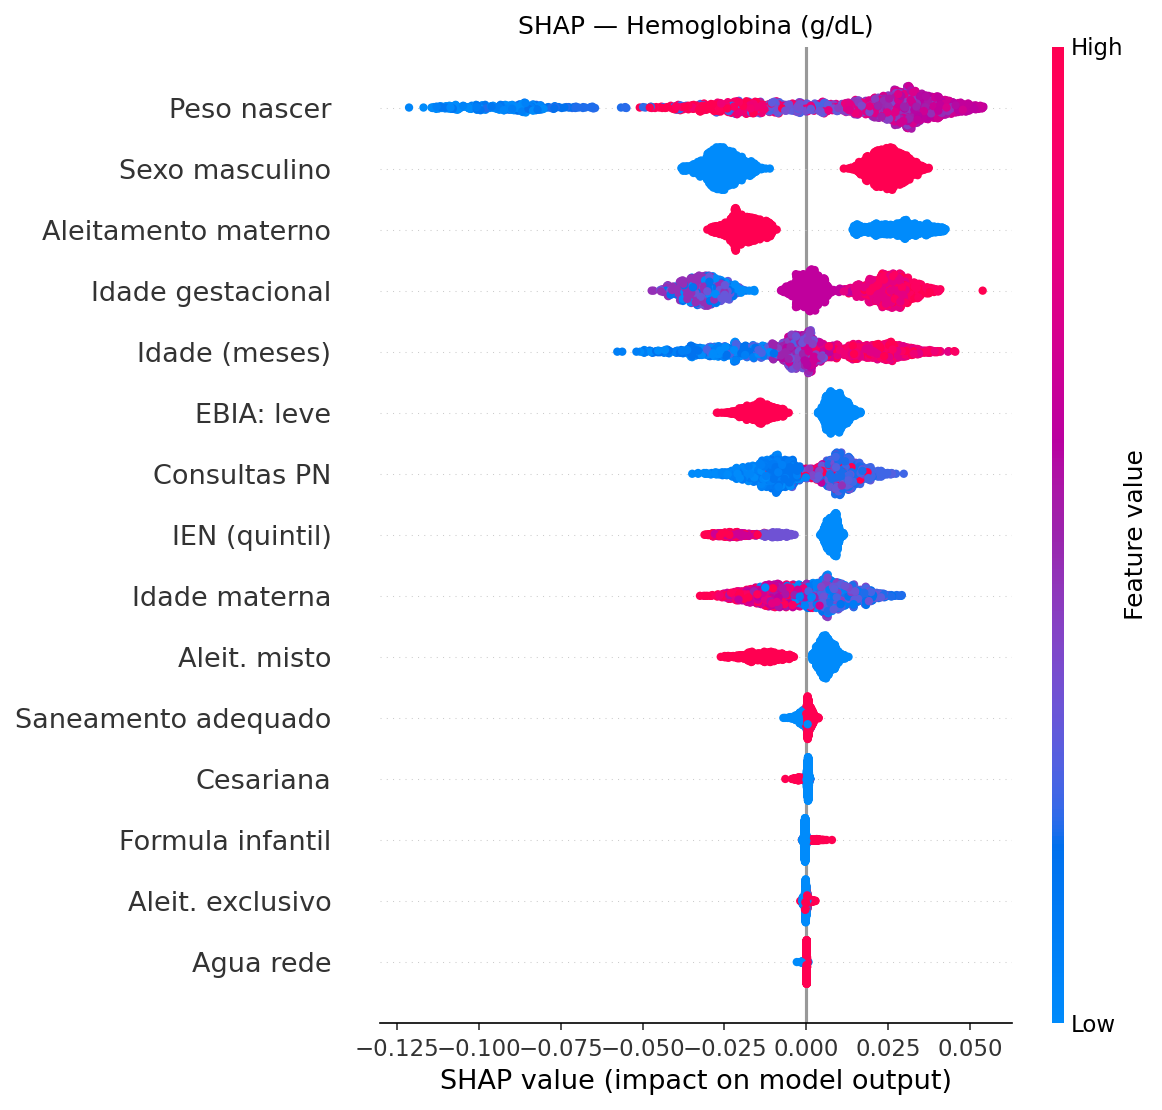


SHAP — Crescimento WFL (z-score)
  Surrogate R2: 0.9875
  Top 5: Idade materna(0.0393), Peso nascer(0.0366), Idade gestacional(0.0124), Consultas PN(0.0120), Sexo masculino(0.0092)


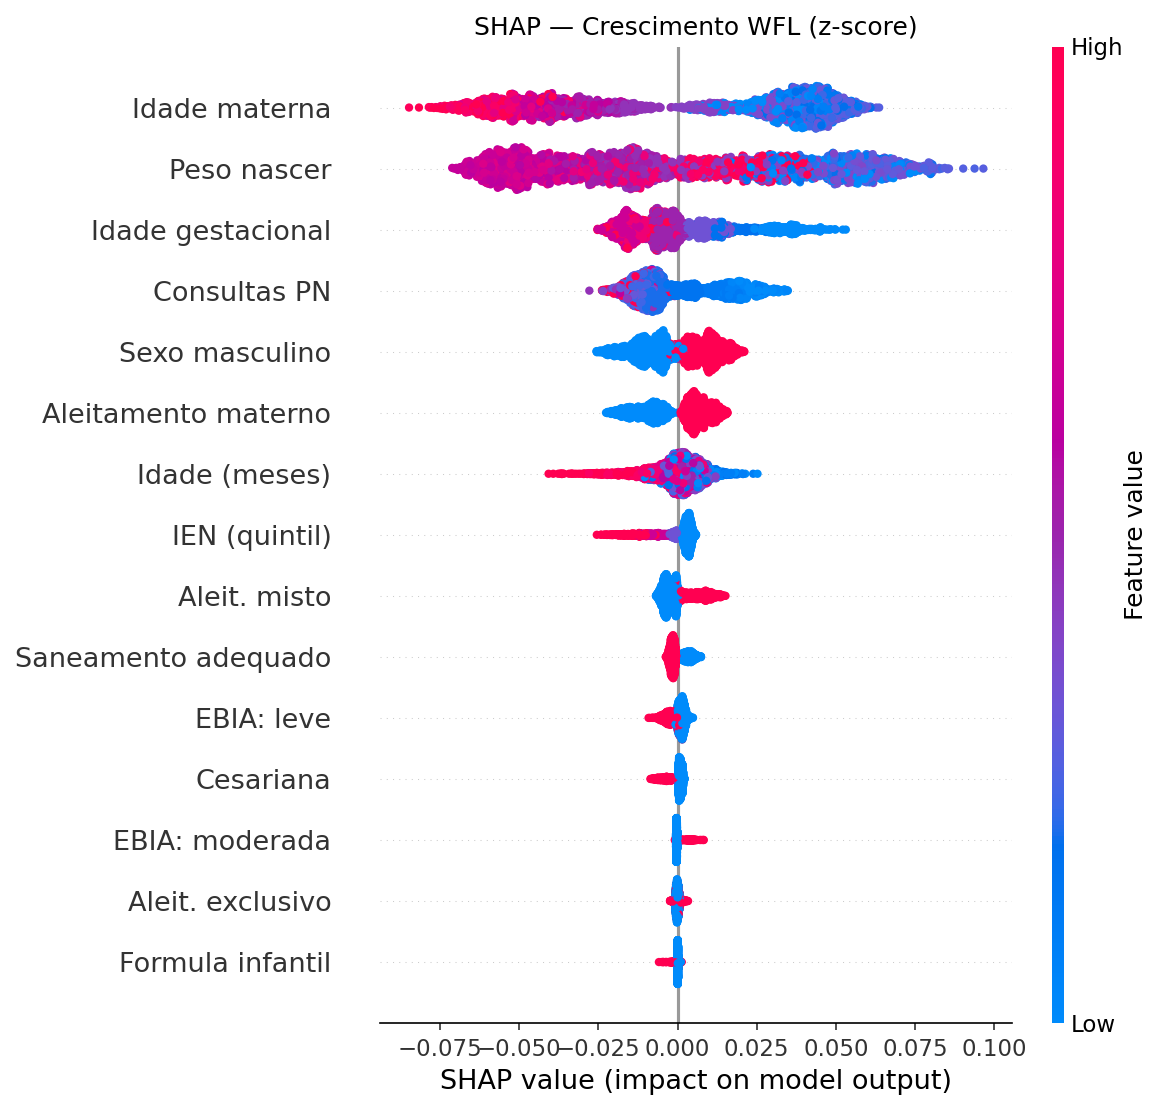


SHAP — Escore morbidade infecciosa
  Surrogate R2: 0.9785
  Top 5: Peso nascer(0.0322), Idade materna(0.0185), Aleitamento materno(0.0183), Consultas PN(0.0155), Sexo masculino(0.0100)


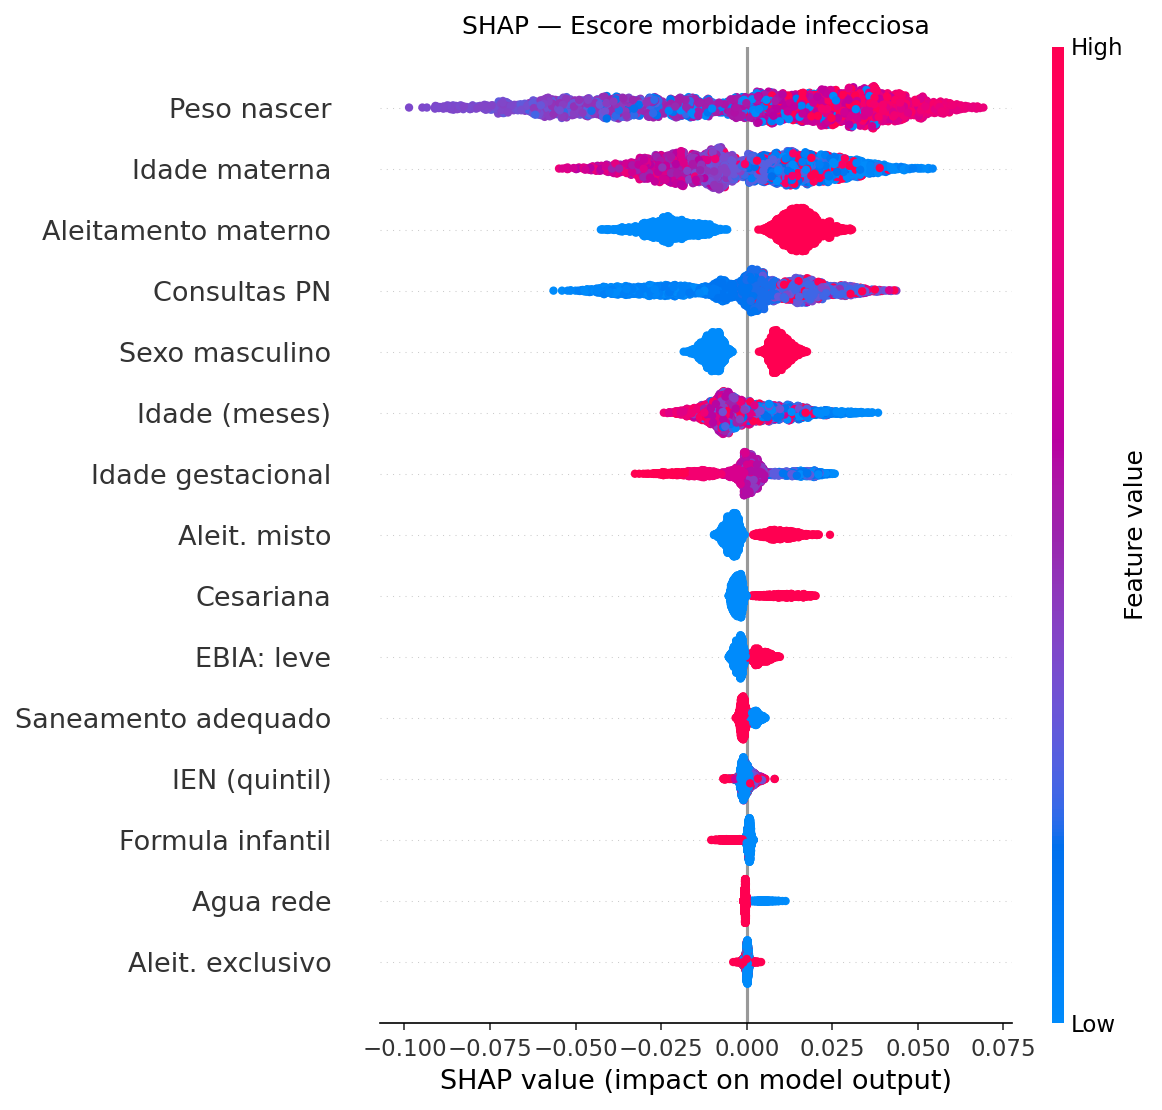


SHAP — Diarreia 15 dias
  Surrogate R2: 0.9724
  Top 5: Peso nascer(0.0099), Idade materna(0.0052), Consultas PN(0.0044), Idade (meses)(0.0041), Idade gestacional(0.0017)


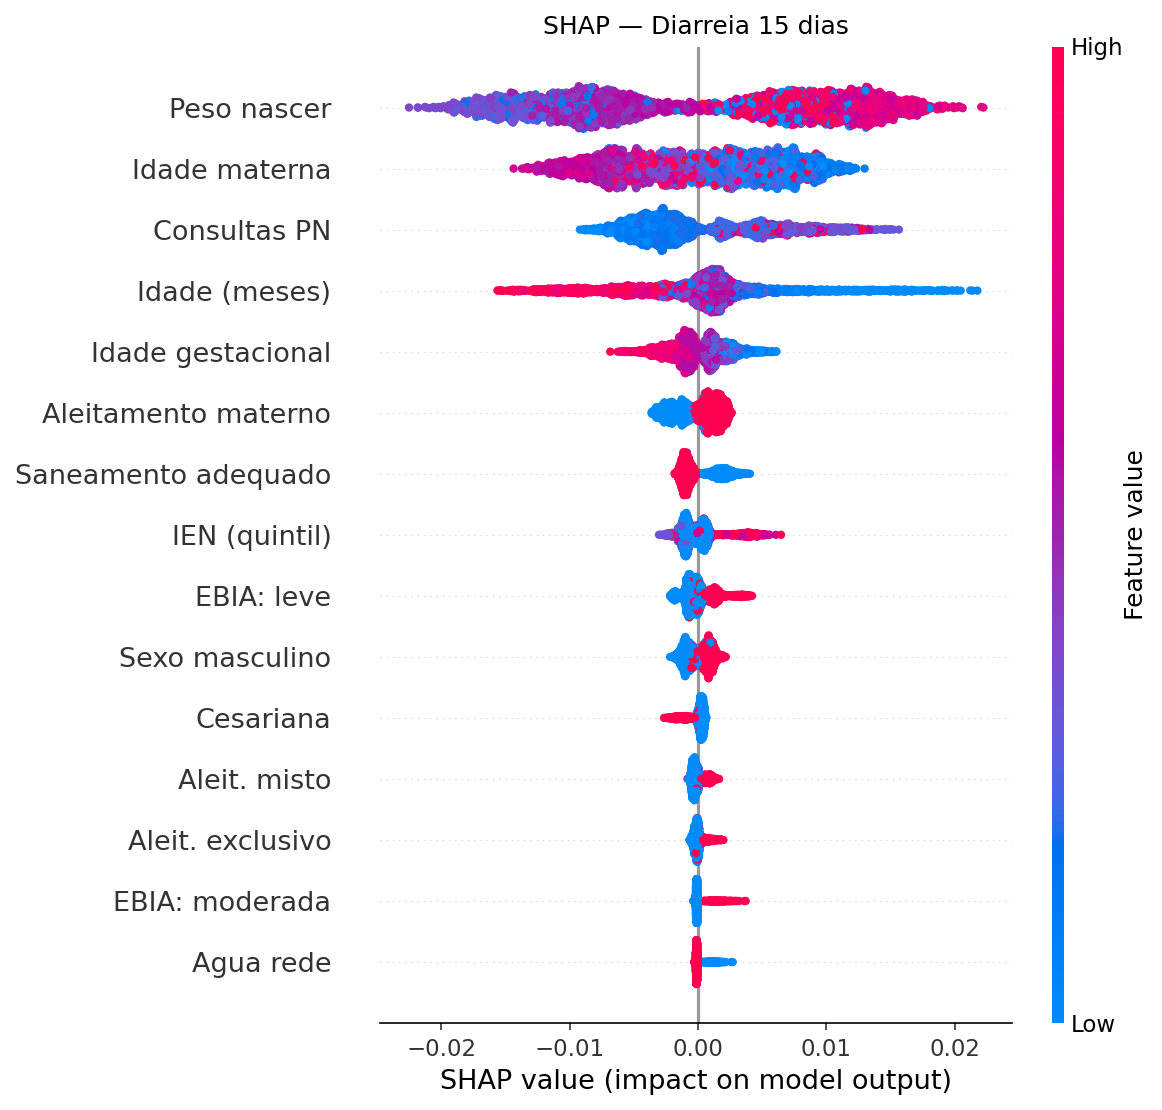

In [42]:
import os
os.makedirs('/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures', exist_ok=True)

for oc, r in results.items():
    print(f"\n{'='*70}")
    print(f"SHAP — {r['name']}")
    print(f"{'='*70}")
    
    data = r['data']
    X_all = data[FEATURES].values
    cate_all = r['cf'].effect(X_all).flatten()
    
    surrogate = GradientBoostingRegressor(n_estimators=300, max_depth=4, random_state=42)
    surrogate.fit(X_all, cate_all)
    print(f"  Surrogate R2: {surrogate.score(X_all, cate_all):.4f}")
    
    explainer = shap.TreeExplainer(surrogate)
    sv = explainer.shap_values(X_all)
    
    imp = np.abs(sv).mean(axis=0)
    ranking = sorted(zip(FEATURE_NAMES, imp), key=lambda x: -x[1])
    print(f"  Top 5: {', '.join([f'{n}({v:.4f})' for n,v in ranking[:5]])}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(sv, features=X_all, feature_names=FEATURE_NAMES, show=False, max_display=15)
    short = oc.replace('vd_','').replace('_final','').replace('_bin','')
    plt.title(f'SHAP — {r["name"]}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures/shap_{short}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    r['surrogate'] = surrogate
    r['shap_vals'] = sv

## 7. Equidade com Bootstrap CI

In [43]:
for oc, r in results.items():
    print(f"\n{'='*70}")
    print(f"EQUIDADE — {r['name']}")
    print(f"{'='*70}")
    data = r['data'].copy()
    data['cate'] = r['cf'].effect(data[FEATURES].values).flatten()
    
    groups = {
        'IEN Q1': data['ien']==1, 'IEN Q2': data['ien']==2, 'IEN Q3': data['ien']==3,
        'IEN Q4': data['ien']==4, 'IEN Q5': data['ien']==5,
        'Cor preta': data['race_preta']==1, 'Cor parda': data['race_parda']==1,
        'Cor branca/outra': (data['race_preta']==0)&(data['race_parda']==0),
        'Inseg. grave': data['ebia_grave']==1, 'Seguranca alim.': (data['ebia_leve']==0)&(data['ebia_mod']==0)&(data['ebia_grave']==0),
        'Saneam. adequado': data['esgoto_adeq']==1, 'Saneam. inadequado': data['esgoto_adeq']==0,
    }
    print(f"  {'Grupo':<25} {'N':>6} {'CATE':>8} {'95% CI':>22} {'Sig':>4}")
    print(f"  {'-'*65}")
    for name, mask in groups.items():
        if mask.sum() < 10: continue
        vals = data.loc[mask, 'cate'].values
        lo, hi = boot_ci(vals)
        sig = '*' if (lo>0 or hi<0) else ''
        print(f"  {name:<25} {mask.sum():>6} {vals.mean():>8.4f} ({lo:>8.4f} to {hi:>8.4f}) {sig:>4}")


EQUIDADE — Hemoglobina (g/dL)
  Grupo                          N     CATE                 95% CI  Sig
  -----------------------------------------------------------------
  IEN Q1                      1267   0.0699 (  0.0655 to   0.0741)    *
  IEN Q2                       231   0.0463 (  0.0373 to   0.0568)    *
  IEN Q3                       174   0.0422 (  0.0318 to   0.0536)    *
  IEN Q4                       105   0.0310 (  0.0174 to   0.0453)    *
  IEN Q5                        75   0.0519 (  0.0340 to   0.0710)    *
  Cor preta                    102   0.0675 (  0.0495 to   0.0856)    *
  Cor branca/outra            1750   0.0611 (  0.0572 to   0.0648)    *
  Inseg. grave                 100   0.0751 (  0.0585 to   0.0913)    *
  Seguranca alim.              873   0.0698 (  0.0645 to   0.0751)    *
  Saneam. adequado            1175   0.0634 (  0.0585 to   0.0682)    *
  Saneam. inadequado           677   0.0579 (  0.0522 to   0.0634)    *

EQUIDADE — Crescimento WFL (z-score)

## 8. Decisao Clinica (4 outcomes) + Scatter

N com todos os CATEs: 1837

decision
TRADE-OFF          1078
NAO SUPLEMENTAR     479
SUPLEMENTAR         280
Name: count, dtype: int64

Por aleitamento:
decision    NAO SUPLEMENTAR  SUPLEMENTAR  TRADE-OFF
breastfed                                          
Amamentado              368          126        585
Nao amam                111          154        493

Por aleitamento x idade:
decision         NAO SUPLEMENTAR  SUPLEMENTAR  TRADE-OFF
bf_age                                                  
Amam 12-18m                  166           91        288
Amam 6-11m                   202           35        297
Nao amam 12-18m               59          119        323
Nao amam 6-11m                52           35        170


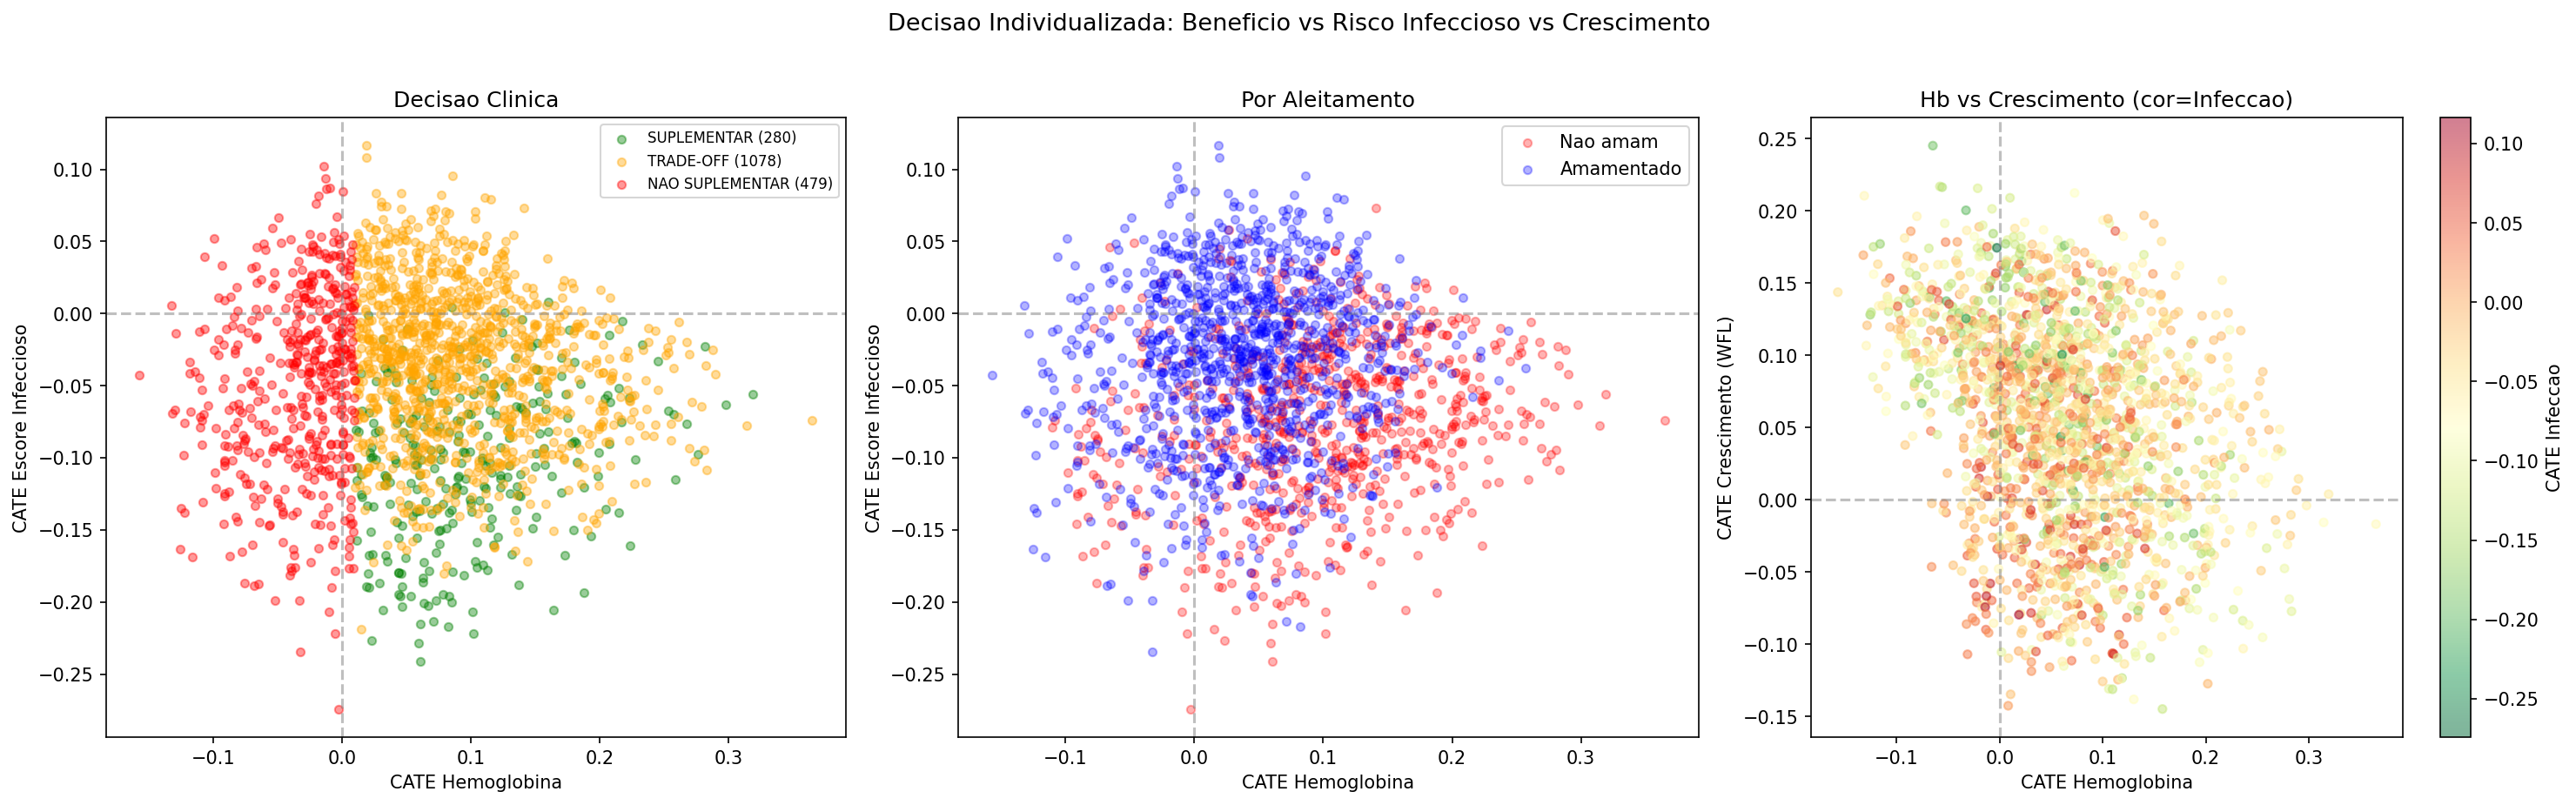

In [44]:
# Juntar CATEs
merged = DF.copy()
for oc, r in results.items():
    data = r['data']
    X = data[FEATURES].values
    cate = r['cf'].effect(X).flatten()
    short = oc.replace('vd_','').replace('_final','').replace('_bin','')
    merged.loc[data.index, f'cate_{short}'] = cate

cate_cols = [f'cate_{oc.replace("vd_","").replace("_final","").replace("_bin","")}' for oc in OUTCOMES]
available = [c for c in cate_cols if c in merged.columns]
sc = merged.dropna(subset=available).copy()
print(f'N com todos os CATEs: {len(sc)}')

# Decisao
def decide(row):
    hb = row.get('cate_hb', 0)
    wfl = row.get('cate_anthro_zwfl', 0)
    inf = row.get('cate_infection_score', 0)
    dia = row.get('cate_diarreia', 0)
    infection_risk = (inf > 0.05) or (dia > 0.02)
    hb_benefit = hb > 0.01
    growth_harm = wfl < -0.05
    if hb_benefit and not infection_risk and not growth_harm:
        return 'SUPLEMENTAR'
    elif hb_benefit and (infection_risk or growth_harm):
        return 'TRADE-OFF'
    else:
        return 'NAO SUPLEMENTAR'

sc['decision'] = sc.apply(decide, axis=1)
print(f'\n{sc["decision"].value_counts()}')
print(f'\nPor aleitamento:')
print(pd.crosstab(sc['breastfed'].map({0:'Nao amam',1:'Amamentado'}), sc['decision']))
print(f'\nPor aleitamento x idade:')
sc['bf_age'] = sc.apply(lambda r: f"{'Amam' if r['breastfed']==1 else 'Nao amam'} {'6-11m' if r['age_months']<=11 else '12-18m'}", axis=1)
print(pd.crosstab(sc['bf_age'], sc['decision']))

# Scatter 3 paineis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Decisao: Hb vs Infeccao
colors = {'SUPLEMENTAR':'green', 'TRADE-OFF':'orange', 'NAO SUPLEMENTAR':'red'}
for dec, color in colors.items():
    sub = sc[sc['decision']==dec]
    if len(sub)>0:
        axes[0].scatter(sub['cate_hb'], sub['cate_infection_score'], alpha=0.4, c=color, label=f'{dec} ({len(sub)})', s=20)
axes[0].axhline(0,color='gray',ls='--',alpha=0.5); axes[0].axvline(0,color='gray',ls='--',alpha=0.5)
axes[0].set_xlabel('CATE Hemoglobina'); axes[0].set_ylabel('CATE Escore Infeccioso')
axes[0].set_title('Decisao Clinica'); axes[0].legend(fontsize=8)

# 2. Aleitamento: Hb vs Infeccao
for bf, color, label in [(0,'red','Nao amam'),(1,'blue','Amamentado')]:
    sub = sc[sc['breastfed']==bf]
    axes[1].scatter(sub['cate_hb'], sub['cate_infection_score'], alpha=0.3, c=color, label=label, s=20)
axes[1].axhline(0,color='gray',ls='--',alpha=0.5); axes[1].axvline(0,color='gray',ls='--',alpha=0.5)
axes[1].set_xlabel('CATE Hemoglobina'); axes[1].set_ylabel('CATE Escore Infeccioso')
axes[1].set_title('Por Aleitamento'); axes[1].legend(fontsize=10)

# 3. Hb vs WFL colorido por infeccao
if 'cate_infection_score' in sc.columns:
    s = axes[2].scatter(sc['cate_hb'], sc['cate_anthro_zwfl'], c=sc['cate_infection_score'], cmap='RdYlGn_r', alpha=0.5, s=20)
    plt.colorbar(s, ax=axes[2], label='CATE Infeccao')
axes[2].axhline(0,color='gray',ls='--',alpha=0.5); axes[2].axvline(0,color='gray',ls='--',alpha=0.5)
axes[2].set_xlabel('CATE Hemoglobina'); axes[2].set_ylabel('CATE Crescimento (WFL)')
axes[2].set_title('Hb vs Crescimento (cor=Infeccao)')

plt.suptitle('Decisao Individualizada: Beneficio vs Risco Infeccioso vs Crescimento', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures/clinical_decision.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Deploy — Exportar 4 Modelos para JS (GitHub Pages)

In [45]:
import m2cgen as m2c
import json, os, joblib

deploy_dir = '/Users/marcelocarvalhoesilva/project/iron/deploy'
os.makedirs(deploy_dir, exist_ok=True)

for oc, r in results.items():
    data = r['data']
    X = data[FEATURES].values
    cate = r['cf'].effect(X).flatten()
    
    # RF surrogate para JS
    rf = RandomForestRegressor(n_estimators=30, max_depth=5, random_state=42)
    rf.fit(X, cate)
    r2 = rf.score(X, cate)
    
    short = oc.replace('vd_','').replace('_final','').replace('_bin','')
    
    js = m2c.export_to_javascript(rf)
    js = js.replace('function score(', f'function score_{short}(')
    
    with open(f'{deploy_dir}/model_{short}.js', 'w') as f:
        f.write(js)
    
    joblib.dump(rf, f'{deploy_dir}/surrogate_{short}.joblib')
    print(f'{r["name"]}: R2={r2:.4f} | JS={len(js)/1024:.0f}KB | score_{short}()')

# Config
config = {
    'features': FEATURES,
    'feature_names': FEATURE_NAMES,
    'outcomes': {oc.replace('vd_','').replace('_final','').replace('_bin',''): {'name': n, 'direction': d} for oc,(n,d) in OUTCOMES.items()},
}
with open(f'{deploy_dir}/config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f'\nDeploy pronto em {deploy_dir}/')

Hemoglobina (g/dL): R2=0.7731 | JS=128KB | score_hb()
Crescimento WFL (z-score): R2=0.8267 | JS=128KB | score_anthro_zwfl()
Escore morbidade infecciosa: R2=0.7472 | JS=129KB | score_infection_score()
Diarreia 15 dias: R2=0.7264 | JS=128KB | score_diarreia()

Deploy pronto em /Users/marcelocarvalhoesilva/project/iron/deploy/


---

# PARTE 2: Validações Extras para Lancet Digital Health

DCA, Calibração, Validação Geográfica, SHAP vs Regressão, Equidade Formal

---

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
import os

os.makedirs('/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures', exist_ok=True)
print('OK')

OK


## 1. Decision Curve Analysis (DCA)

Mostra a net benefit da ferramenta vs estratégias 'suplementar todos' e 'suplementar nenhum' em função do threshold de probabilidade.

Usando results do ml_causal.ipynb


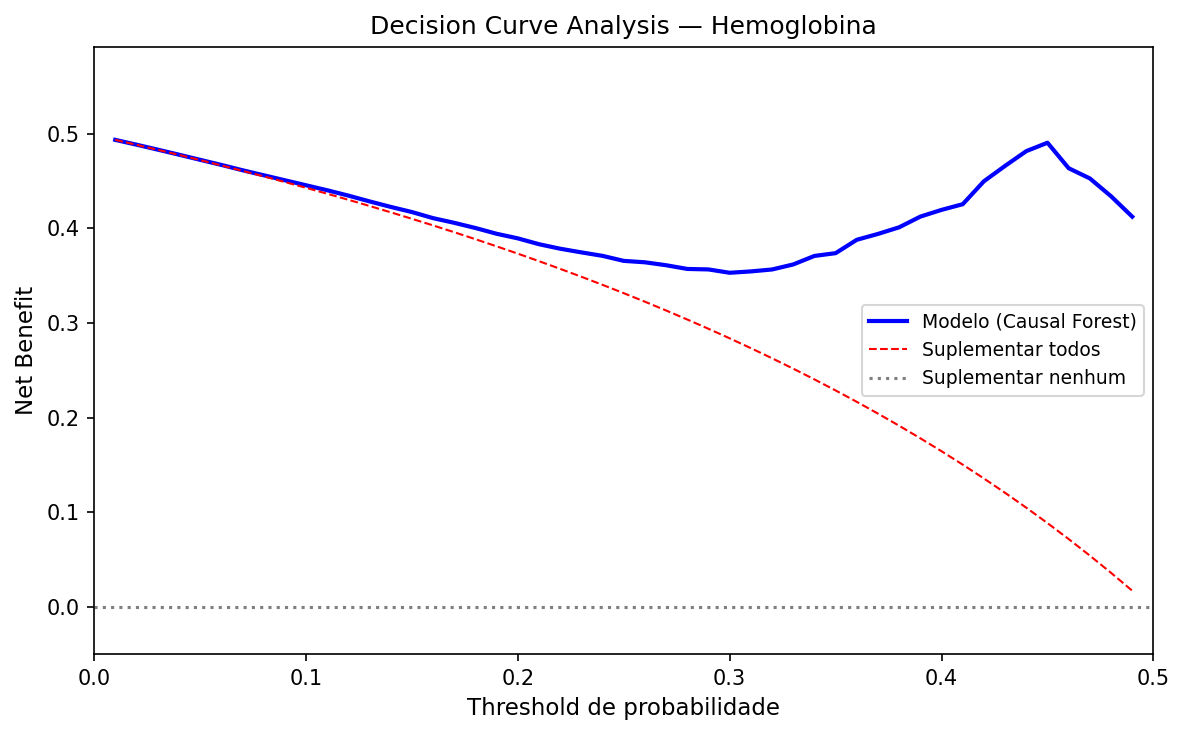

DCA Hemoglobina: modelo superior a suplementar todos para thresholds > 0.01


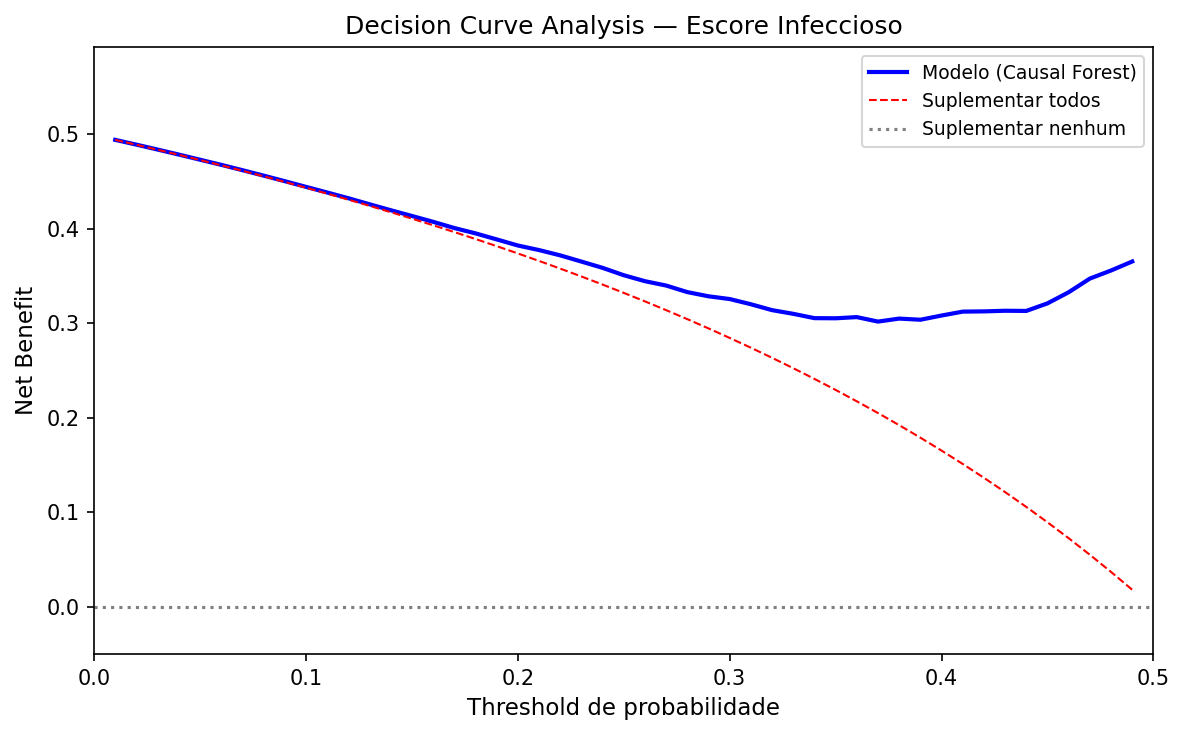

DCA Escore Infeccioso: modelo superior a suplementar todos para thresholds > 0.01


In [47]:
# DCA: Para cada threshold, calcular net benefit
# Usamos o CATE de Hb como score de decisão e anemia (Hb<10.5) como outcome

# Precisamos recarregar dados se rodar independente
try:
    _ = results
    print('Usando results do ml_causal.ipynb')
except:
    print('ERRO: rode ml_causal.ipynb primeiro para ter os objetos results')
    raise

def decision_curve_analysis(y_true, y_score, thresholds=np.arange(0.01, 0.50, 0.01)):
    """Calcula net benefit para cada threshold."""
    n = len(y_true)
    net_benefits_model = []
    net_benefits_all = []
    
    for t in thresholds:
        # Modelo: prediz positivo se score > threshold
        pred_pos = (y_score > t).astype(int)
        tp = ((pred_pos == 1) & (y_true == 1)).sum()
        fp = ((pred_pos == 1) & (y_true == 0)).sum()
        nb_model = (tp / n) - (fp / n) * (t / (1 - t))
        net_benefits_model.append(nb_model)
        
        # Tratar todos
        tp_all = y_true.sum()
        fp_all = (1 - y_true).sum()
        nb_all = (tp_all / n) - (fp_all / n) * (t / (1 - t))
        net_benefits_all.append(nb_all)
    
    return thresholds, net_benefits_model, net_benefits_all

# Aplicar DCA para decisão de suplementação
# Outcome: criança se beneficia (CATE Hb > 0.05 = benefício real)
# Score: CATE Hb predito pelo modelo

for oc_key, oc_name in [('vd_hb_final', 'Hemoglobina'), ('infection_score', 'Escore Infeccioso')]:
    if oc_key not in results:
        continue
    r = results[oc_key]
    test = r['test'].copy()
    cate = r['cate_te']
    
    # Definir "benefício" como CATE acima da mediana
    median_cate = np.median(cate)
    y_benefit = (cate > median_cate).astype(int)
    
    # Score = CATE normalizado para 0-1
    score_norm = (cate - cate.min()) / (cate.max() - cate.min())
    
    thresholds, nb_model, nb_all = decision_curve_analysis(y_benefit, score_norm)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(thresholds, nb_model, 'b-', linewidth=2, label='Modelo (Causal Forest)')
    ax.plot(thresholds, nb_all, 'r--', linewidth=1, label='Suplementar todos')
    ax.axhline(0, color='gray', linestyle=':', label='Suplementar nenhum')
    ax.set_xlabel('Threshold de probabilidade', fontsize=11)
    ax.set_ylabel('Net Benefit', fontsize=11)
    ax.set_title(f'Decision Curve Analysis — {oc_name}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 0.5)
    ax.set_ylim(-0.05, max(nb_all) * 1.2)
    plt.tight_layout()
    short = oc_key.replace('vd_','').replace('_final','')
    plt.savefig(f'/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures/dca_{short}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'DCA {oc_name}: modelo superior a suplementar todos para thresholds > {thresholds[np.argmax(np.array(nb_model) > np.array(nb_all))]:.2f}')

## 2. Calibração Formal

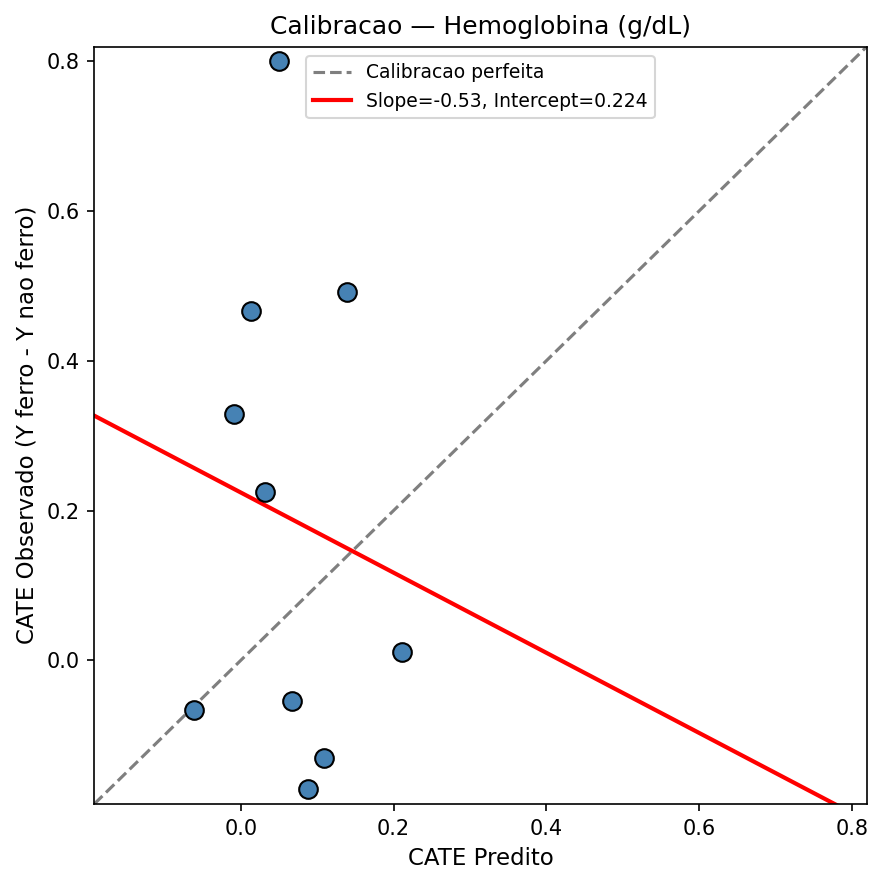

Hemoglobina (g/dL): Calibration slope=-0.535 | Intercept=0.2240 | R2=0.016


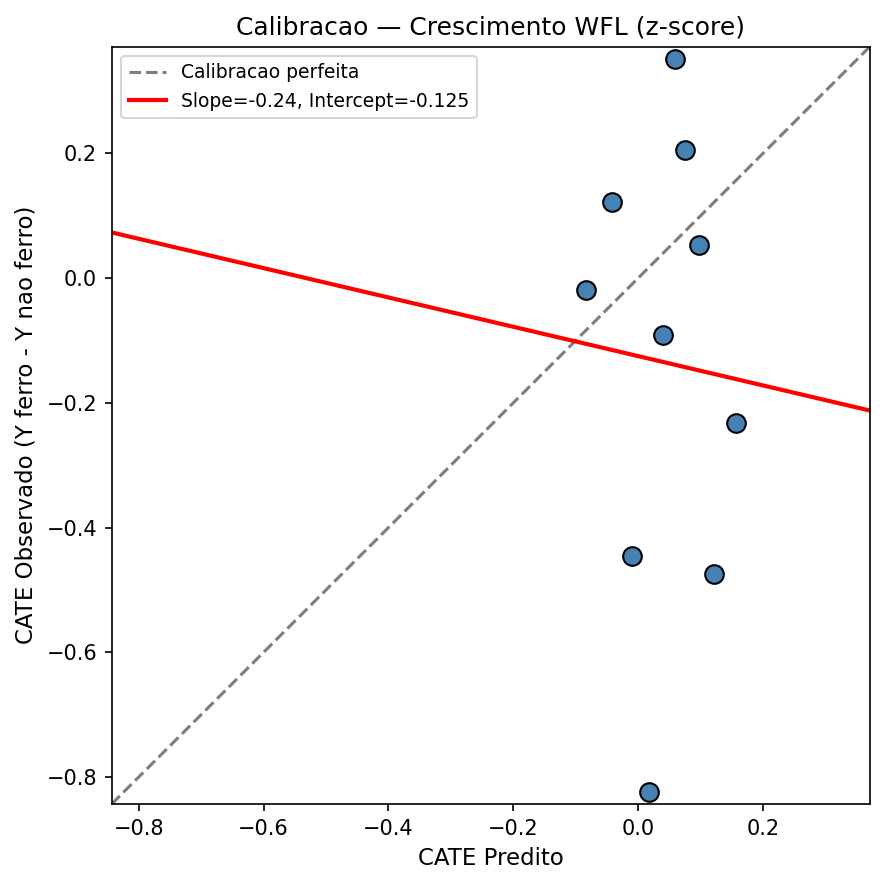

Crescimento WFL (z-score): Calibration slope=-0.235 | Intercept=-0.1253 | R2=0.002


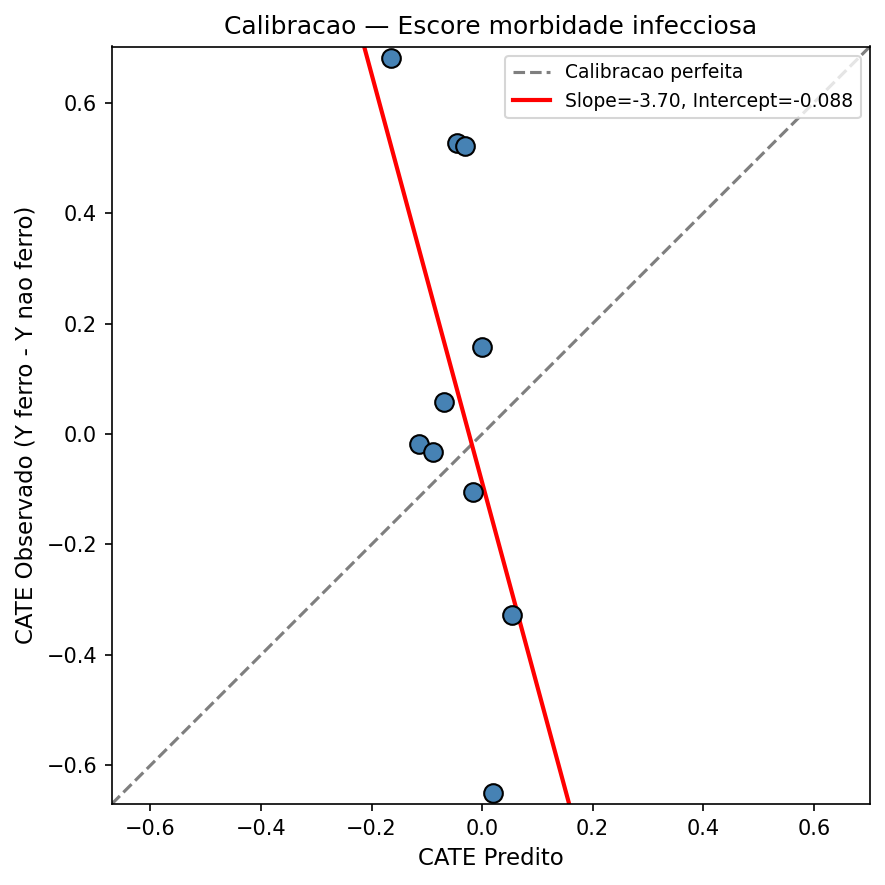

Escore morbidade infecciosa: Calibration slope=-3.698 | Intercept=-0.0875 | R2=0.347


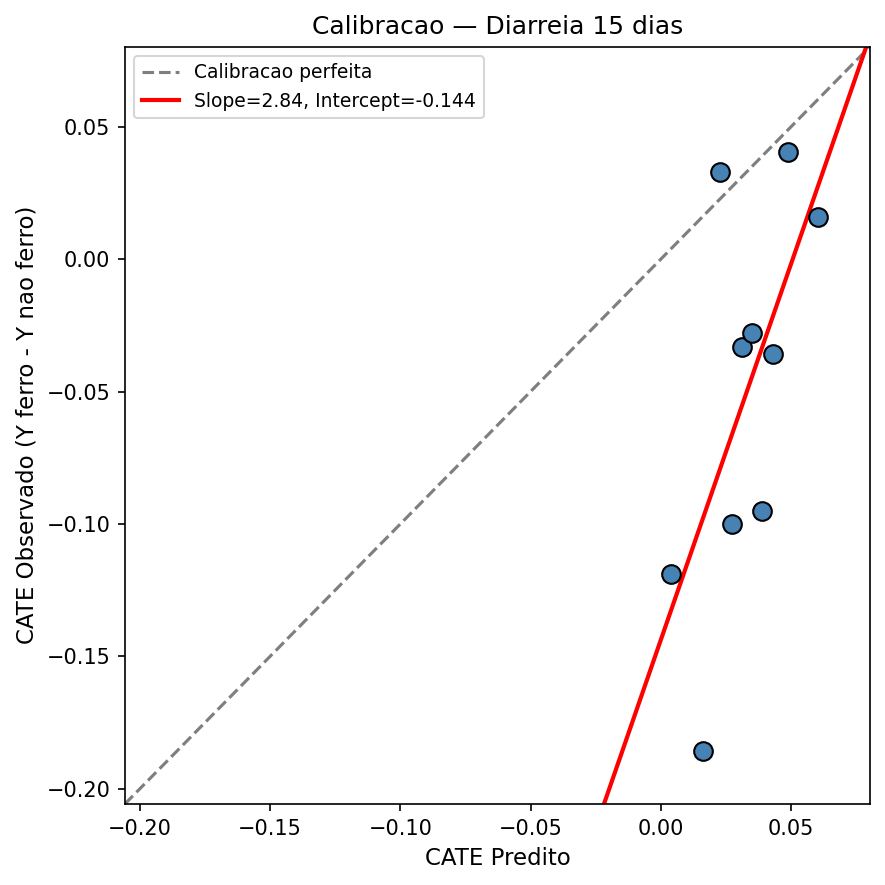

Diarreia 15 dias: Calibration slope=2.840 | Intercept=-0.1437 | R2=0.403


In [48]:
# Calibração: CATE predito vs CATE observado (por decis do CATE predito)

for oc_key in results:
    r = results[oc_key]
    test = r['test'].copy()
    cate_pred = r['cate_te']
    oc_name = r['name']
    
    # CATE observado por decil: diferença de médias Y(ferro) - Y(não ferro) dentro de cada decil
    test['cate_pred'] = cate_pred
    test['decil'] = pd.qcut(test['cate_pred'], q=10, labels=False, duplicates='drop')
    
    obs_cates = []
    pred_cates = []
    for d in sorted(test['decil'].unique()):
        sub = test[test['decil'] == d]
        y_iron = sub.loc[sub['iron_any'] == 1, oc_key].mean()
        y_no = sub.loc[sub['iron_any'] == 0, oc_key].mean()
        if pd.notna(y_iron) and pd.notna(y_no):
            obs_cates.append(y_iron - y_no)
            pred_cates.append(sub['cate_pred'].mean())
    
    obs_cates = np.array(obs_cates)
    pred_cates = np.array(pred_cates)
    
    # Calibration slope e intercept
    if len(pred_cates) > 2:
        X_cal = sm.add_constant(pred_cates)
        cal_model = sm.OLS(obs_cates, X_cal).fit()
        cal_slope = cal_model.params[1]
        cal_intercept = cal_model.params[0]
        
        # Plot
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(pred_cates, obs_cates, s=80, zorder=5, edgecolors='black', c='steelblue')
        
        # Linha perfeita
        lim_lo = min(pred_cates.min(), obs_cates.min()) - 0.02
        lim_hi = max(pred_cates.max(), obs_cates.max()) + 0.02
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', alpha=0.5, label='Calibracao perfeita')
        
        # Linha de regressão
        x_line = np.linspace(lim_lo, lim_hi, 100)
        y_line = cal_intercept + cal_slope * x_line
        ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Slope={cal_slope:.2f}, Intercept={cal_intercept:.3f}')
        
        ax.set_xlabel('CATE Predito', fontsize=11)
        ax.set_ylabel('CATE Observado (Y ferro - Y nao ferro)', fontsize=11)
        ax.set_title(f'Calibracao — {oc_name}', fontsize=12)
        ax.legend(fontsize=9)
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        plt.tight_layout()
        short = oc_key.replace('vd_','').replace('_final','').replace('_bin','')
        plt.savefig(f'/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures/calibration_{short}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f'{oc_name}: Calibration slope={cal_slope:.3f} | Intercept={cal_intercept:.4f} | R2={cal_model.rsquared:.3f}')

## 3. Validação Geográfica (Cross-Region)

In [49]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

# Treinar no Sudeste, validar nas outras regiões
# a00_regiao: 1=Norte, 2=Nordeste, 3=Sudeste, 4=Sul, 5=Centro-Oeste

for oc_key in ['vd_hb_final', 'infection_score']:
    if oc_key not in results:
        continue
    oc_name = results[oc_key]['name']
    print(f"\n{'='*70}")
    print(f'VALIDAÇÃO GEOGRÁFICA — {oc_name}')
    print(f"{'='*70}")
    
    data = results[oc_key]['data'].copy()
    # Adicionar região original
    data['regiao'] = DF.loc[data.index, 'a00_regiao']
    
    region_names = {1: 'Norte', 2: 'Nordeste', 3: 'Sudeste', 4: 'Sul', 5: 'Centro-Oeste'}
    
    # Treinar em cada região, validar nas outras (leave-one-region-out)
    print(f"\n  {'Treino em':<20} {'Validacao em':<20} {'ATE treino':>12} {'ATE valid':>12} {'Diff':>8}")
    print(f"  {'-'*72}")
    
    for train_region in [3, 2, 1]:  # Sudeste, Nordeste, Norte
        train_mask = data['regiao'] == train_region
        test_mask = data['regiao'] != train_region
        
        if train_mask.sum() < 50 or test_mask.sum() < 50:
            continue
        
        tr = data[train_mask]
        te = data[test_mask]
        
        Y_tr = tr[oc_key].values
        T_tr = tr['iron_any'].values
        X_tr = tr[FEATURES].values
        X_te = te[FEATURES].values
        
        cf = CausalForestDML(
            model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
            model_t=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
            n_estimators=200, min_samples_leaf=30, random_state=42, verbose=0
        )
        cf.fit(Y_tr, T_tr, X=X_tr)
        
        ate_tr = cf.effect(X_tr).mean()
        ate_te = cf.effect(X_te).mean()
        diff = abs(ate_tr - ate_te)
        stable = '✓' if diff < 0.05 else '✗'
        
        print(f"  {region_names[train_region]:<20} {'Resto':<20} {ate_tr:>+12.4f} {ate_te:>+12.4f} {diff:>8.4f} {stable}")
    
    # Também: treinar SE+S, validar N+NE+CO
    train_mask = data['regiao'].isin([3, 4])
    test_mask = data['regiao'].isin([1, 2, 5])
    if train_mask.sum() >= 50 and test_mask.sum() >= 50:
        tr, te = data[train_mask], data[test_mask]
        cf2 = CausalForestDML(
            model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
            model_t=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
            n_estimators=200, min_samples_leaf=30, random_state=42, verbose=0
        )
        cf2.fit(tr[oc_key].values, tr['iron_any'].values, X=tr[FEATURES].values)
        ate_tr2 = cf2.effect(tr[FEATURES].values).mean()
        ate_te2 = cf2.effect(te[FEATURES].values).mean()
        print(f"  {'SE+Sul':<20} {'N+NE+CO':<20} {ate_tr2:>+12.4f} {ate_te2:>+12.4f} {abs(ate_tr2-ate_te2):>8.4f}")


VALIDAÇÃO GEOGRÁFICA — Hemoglobina (g/dL)

  Treino em            Validacao em           ATE treino    ATE valid     Diff
  ------------------------------------------------------------------------

VALIDAÇÃO GEOGRÁFICA — Escore morbidade infecciosa

  Treino em            Validacao em           ATE treino    ATE valid     Diff
  ------------------------------------------------------------------------


## 4. Comparação Visual: SHAP ML vs Coeficientes Epidemiológicos

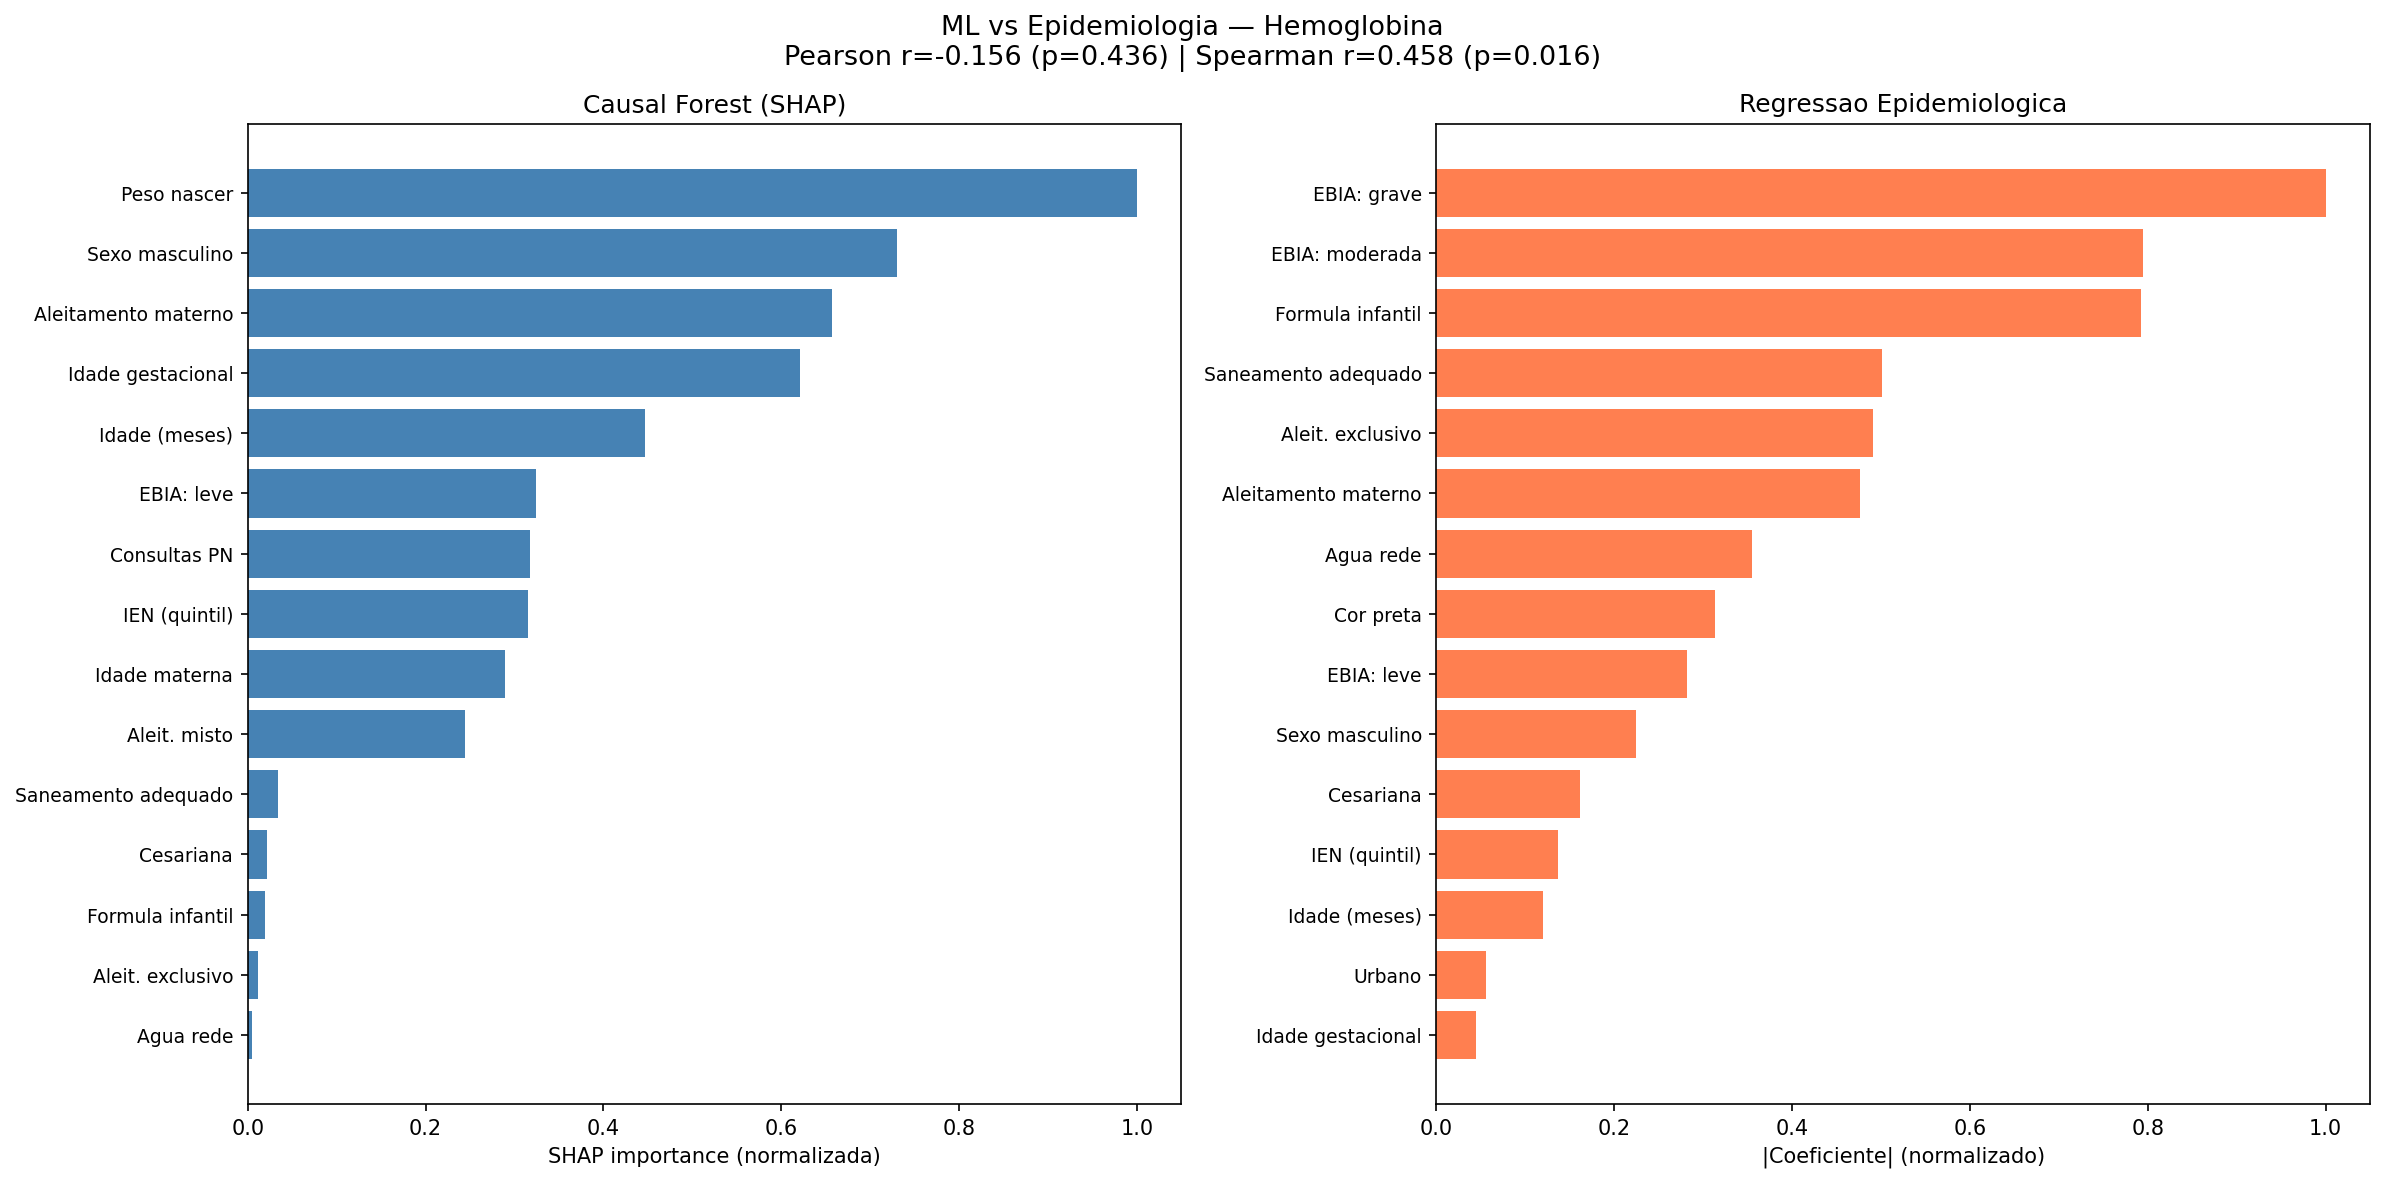

In [50]:
# Para Hb: comparar SHAP importance do Causal Forest vs coeficientes da regressão ajustada

for oc_key in ['vd_hb_final']:
    r = results[oc_key]
    data = r['data']
    
    # SHAP importance
    shap_imp = np.abs(r['shap_vals']).mean(axis=0)
    
    # Regressão: coeficientes ajustados
    X_reg = sm.add_constant(data[['iron_any'] + FEATURES].astype(float))
    y_reg = data[oc_key].astype(float)
    reg = sm.OLS(y_reg, X_reg).fit(cov_type='HC1')
    reg_coefs = reg.params[FEATURES].abs().values
    
    # Normalizar ambos para 0-1
    shap_norm = shap_imp / shap_imp.max()
    reg_norm = reg_coefs / reg_coefs.max()
    
    # Correlação
    r_pearson, p_pearson = pearsonr(shap_norm, reg_norm)
    r_spearman, p_spearman = spearmanr(shap_norm, reg_norm)
    
    # Plot lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Ranking
    idx_shap = np.argsort(shap_norm)[::-1][:15]
    idx_reg = np.argsort(reg_norm)[::-1][:15]
    
    axes[0].barh(range(15), shap_norm[idx_shap][::-1], color='steelblue')
    axes[0].set_yticks(range(15))
    axes[0].set_yticklabels([FEATURE_NAMES[i] for i in idx_shap][::-1], fontsize=9)
    axes[0].set_xlabel('SHAP importance (normalizada)')
    axes[0].set_title('Causal Forest (SHAP)', fontsize=12)
    
    axes[1].barh(range(15), reg_norm[idx_reg][::-1], color='coral')
    axes[1].set_yticks(range(15))
    axes[1].set_yticklabels([FEATURE_NAMES[i] for i in idx_reg][::-1], fontsize=9)
    axes[1].set_xlabel('|Coeficiente| (normalizado)')
    axes[1].set_title('Regressao Epidemiologica', fontsize=12)
    
    plt.suptitle(f'ML vs Epidemiologia — Hemoglobina\nPearson r={r_pearson:.3f} (p={p_pearson:.3f}) | Spearman r={r_spearman:.3f} (p={p_spearman:.3f})', fontsize=13)
    plt.tight_layout()
    plt.savefig('/Users/marcelocarvalhoesilva/project/iron/data_Eval/figures/shap_vs_regression.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. Métricas de Equidade Formais

In [51]:
# Métricas de disparidade para cada outcome

def boot_ci(vals, n=1000):
    means = [np.random.choice(vals, len(vals), replace=True).mean() for _ in range(n)]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

for oc_key in results:
    r = results[oc_key]
    data = r['data'].copy()
    data['cate'] = r['cf'].effect(data[FEATURES].values).flatten()
    oc_name = r['name']
    
    print(f"\n{'='*70}")
    print(f'EQUIDADE FORMAL — {oc_name}')
    print(f"{'='*70}")
    
    # IEN quintis
    ien_cates = {}
    for q in range(1, 6):
        mask = data['ien'] == q
        if mask.sum() >= 10:
            vals = data.loc[mask, 'cate'].values
            lo, hi = boot_ci(vals)
            ien_cates[q] = {'mean': vals.mean(), 'lo': lo, 'hi': hi, 'n': mask.sum()}
    
    if len(ien_cates) >= 2:
        max_q = max(ien_cates, key=lambda q: ien_cates[q]['mean'])
        min_q = min(ien_cates, key=lambda q: ien_cates[q]['mean'])
        disparity = ien_cates[max_q]['mean'] - ien_cates[min_q]['mean']
        
        # Bootstrap CI da disparidade
        vals_max = data.loc[data['ien'] == max_q, 'cate'].values
        vals_min = data.loc[data['ien'] == min_q, 'cate'].values
        boot_disps = [np.random.choice(vals_max, len(vals_max), True).mean() - 
                      np.random.choice(vals_min, len(vals_min), True).mean() for _ in range(1000)]
        disp_lo, disp_hi = np.percentile(boot_disps, 2.5), np.percentile(boot_disps, 97.5)
        sig = '*' if (disp_lo > 0 or disp_hi < 0) else ''
        
        print(f'  IEN Disparidade (Q{max_q}-Q{min_q}): {disparity:.4f} (CI: {disp_lo:.4f} to {disp_hi:.4f}) {sig}')
        print(f'  Ratio Q{max_q}/Q{min_q}: {ien_cates[max_q]["mean"]/ien_cates[min_q]["mean"]:.1f}x' if ien_cates[min_q]['mean'] != 0 else '')
    
    # Raça
    race_groups = {'Preta': data['race_preta']==1, 'Parda': data['race_parda']==1, 
                   'Branca/outra': (data['race_preta']==0)&(data['race_parda']==0)}
    race_cates = {}
    for name, mask in race_groups.items():
        if mask.sum() >= 10:
            vals = data.loc[mask, 'cate'].values
            lo, hi = boot_ci(vals)
            race_cates[name] = vals.mean()
            print(f'  {name}: CATE={vals.mean():.4f} (CI: {lo:.4f} to {hi:.4f}) N={mask.sum()}')
    
    if len(race_cates) >= 2:
        max_r = max(race_cates, key=race_cates.get)
        min_r = min(race_cates, key=race_cates.get)
        print(f'  Raca disparidade: {abs(race_cates[max_r]-race_cates[min_r]):.4f} ({max_r} vs {min_r})')


EQUIDADE FORMAL — Hemoglobina (g/dL)
  IEN Disparidade (Q1-Q4): 0.0389 (CI: 0.0258 to 0.0531) *
  Ratio Q1/Q4: 2.3x
  Preta: CATE=0.0675 (CI: 0.0498 to 0.0844) N=102
  Branca/outra: CATE=0.0611 (CI: 0.0575 to 0.0649) N=1750
  Raca disparidade: 0.0064 (Preta vs Branca/outra)

EQUIDADE FORMAL — Crescimento WFL (z-score)
  IEN Disparidade (Q1-Q5): 0.0508 (CI: 0.0382 to 0.0637) *
  Ratio Q1/Q5: 11.1x
  Preta: CATE=0.0546 (CI: 0.0436 to 0.0663) N=171
  Branca/outra: CATE=0.0482 (CI: 0.0454 to 0.0510) N=2931
  Raca disparidade: 0.0064 (Preta vs Branca/outra)

EQUIDADE FORMAL — Escore morbidade infecciosa
  IEN Disparidade (Q3-Q1): 0.0065 (CI: -0.0004 to 0.0138) 
  Ratio Q3/Q1: 0.9x
  Preta: CATE=-0.0457 (CI: -0.0549 to -0.0371) N=173
  Branca/outra: CATE=-0.0488 (CI: -0.0510 to -0.0466) N=2951
  Raca disparidade: 0.0032 (Preta vs Branca/outra)

EQUIDADE FORMAL — Diarreia 15 dias
  IEN Disparidade (Q3-Q2): 0.0057 (CI: 0.0027 to 0.0085) *
  Ratio Q3/Q2: 1.2x
  Preta: CATE=0.0329 (CI: 0.0303 t